# Brain Tumor MRI Classification

Classification binaire d'images IRM de cerveaux : **tumeur** vs **pas de tumeur**.

**Modèle** : EfficientNet-B0 (transfer learning)  
**Dataset** : sartajbhuvaji/brain-tumor-classification-mri — 3264 images  
**Techniques** : loss pondérée, albumentations, TTA, early stopping, scheduler cosinus

---

## 1. Installation

In [139]:
!pip install -q torch torchvision torchaudio scikit-learn matplotlib seaborn kagglehub pillow tqdm albumentations
print('✅ Installation terminée (avec albumentations).')

✅ Installation terminée (avec albumentations).


## 2. Imports et configuration

Seed fixée à 42 pour la reproductibilité. Détection automatique GPU/CPU.

In [140]:
import os
import random
from pathlib import Path
from typing import Callable, Optional, Sequence
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)
from tqdm import tqdm

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'🎲 Seed : {SEED}')
print(f'🖥️  Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')

🎲 Seed : 42
🖥️  Device : cuda
   GPU : Tesla T4


> **Résultat** : GPU Tesla T4 détecté (Google Colab). Entraînement ~30× plus rapide qu'en CPU.

## 3. Téléchargement du dataset

In [141]:
import kagglehub

# Téléchargement automatique depuis Kaggle
dataset_path = kagglehub.dataset_download('sartajbhuvaji/brain-tumor-classification-mri')
dataset_path = Path(dataset_path)

print(f'📁 Dataset téléchargé dans : {dataset_path}')
print()

# Lister le contenu
for item in sorted(dataset_path.iterdir()):
    if item.is_dir():
        n_files = len(list(item.rglob('*.*')))
        print(f'   📂 {item.name}/ ({n_files} fichiers)')
    else:
        print(f'   📄 {item.name}')

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
📁 Dataset téléchargé dans : /kaggle/input/brain-tumor-classification-mri

   📂 Testing/ (394 fichiers)
   📂 Training/ (2870 fichiers)


In [142]:
# Identifier les dossiers Training et Testing
TRAIN_DIR = dataset_path / 'Training'
TEST_DIR = dataset_path / 'Testing'

# Si la structure est différente, chercher automatiquement
if not TRAIN_DIR.exists():
    for d in dataset_path.rglob('Training'):
        TRAIN_DIR = d
        break
if not TEST_DIR.exists():
    for d in dataset_path.rglob('Testing'):
        TEST_DIR = d
        break

print(f'🏋️ Dossier Training : {TRAIN_DIR}')
print(f'🧪 Dossier Testing  : {TEST_DIR}')

# Compter les images par classe
print()
print('Distribution des images (Training) :')
for cls_dir in sorted(TRAIN_DIR.iterdir()):
    if cls_dir.is_dir():
        n = len([f for f in cls_dir.iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png'}])
        print(f'   {cls_dir.name:20s} : {n:5d} images')

🏋️ Dossier Training : /kaggle/input/brain-tumor-classification-mri/Training
🧪 Dossier Testing  : /kaggle/input/brain-tumor-classification-mri/Testing

Distribution des images (Training) :
   glioma_tumor         :   826 images
   meningioma_tumor     :   822 images
   no_tumor             :   395 images
   pituitary_tumor      :   827 images


> **Résultat** : 2870 images pour Training, 394 pour Testing. Le Testing ne sera utilisé qu'à la toute fin.
>
> | Dossier | Label | Images |
> |---------|-------|--------|
> | glioma_tumor | 1 | 826 |
> | meningioma_tumor | 1 | 822 |
> | pituitary_tumor | 1 | 827 |
> | no_tumor | 0 | 395 |

## 4. Exploration visuelle

### 4.1 Distribution des classes

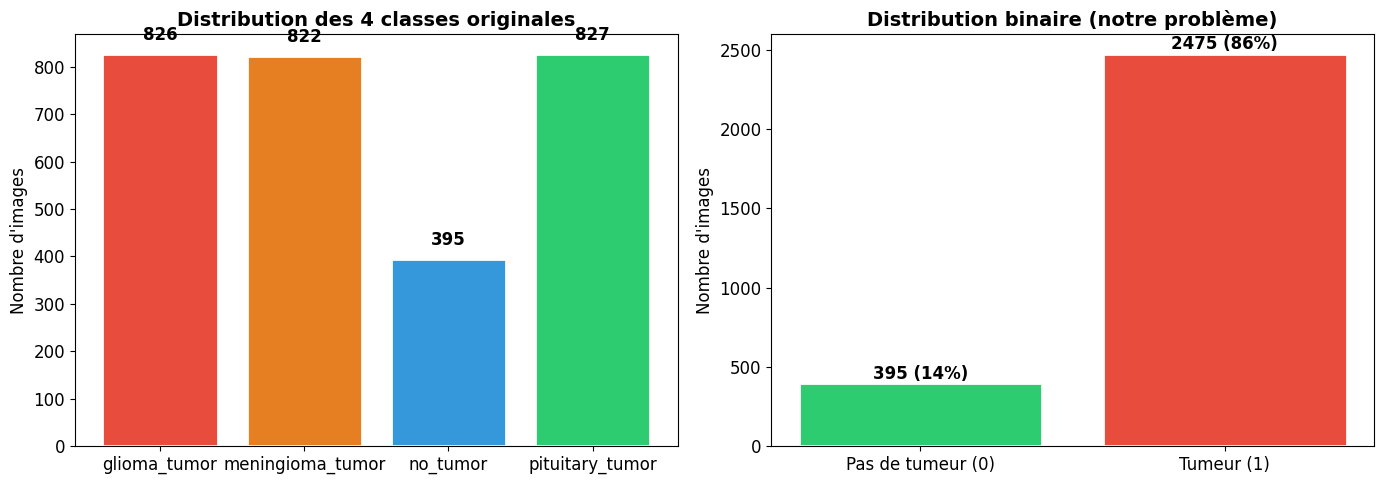


⚠️ Déséquilibre : 86% tumeur vs 14% sain
   → On utilisera une loss pondérée pour compenser.


In [143]:
# ============================================================
# 4.1 — Distribution des classes
# ============================================================

class_counts = {}
for cls_dir in sorted(TRAIN_DIR.iterdir()):
    if cls_dir.is_dir():
        n = len([f for f in cls_dir.iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png'}])
        class_counts[cls_dir.name] = n

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot des 4 classes originales
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Distribution des 4 classes originales', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre d\'images')
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=12)

# Barplot binaire (tumeur vs sain)
tumor = sum(v for k, v in class_counts.items() if k != 'no_tumor')
no_tumor = class_counts.get('no_tumor', 0)
binary = {'Pas de tumeur (0)': no_tumor, 'Tumeur (1)': tumor}
axes[1].bar(binary.keys(), binary.values(), color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
axes[1].set_title('Distribution binaire (notre problème)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nombre d\'images')
for i, (k, v) in enumerate(binary.items()):
    axes[1].text(i, v + 30, f'{v} ({v/sum(binary.values())*100:.0f}%)', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f'\n⚠️ Déséquilibre : {tumor/(tumor+no_tumor)*100:.0f}% tumeur vs {no_tumor/(tumor+no_tumor)*100:.0f}% sain')
print('   → On utilisera une loss pondérée pour compenser.')

> **Déséquilibre sévère** : 86% tumeur vs 14% sain. Corrigé par une loss pondérée (les erreurs sur les sains coûtent 6.27× plus cher).

### 4.2 Exemples d'images IRM par classe

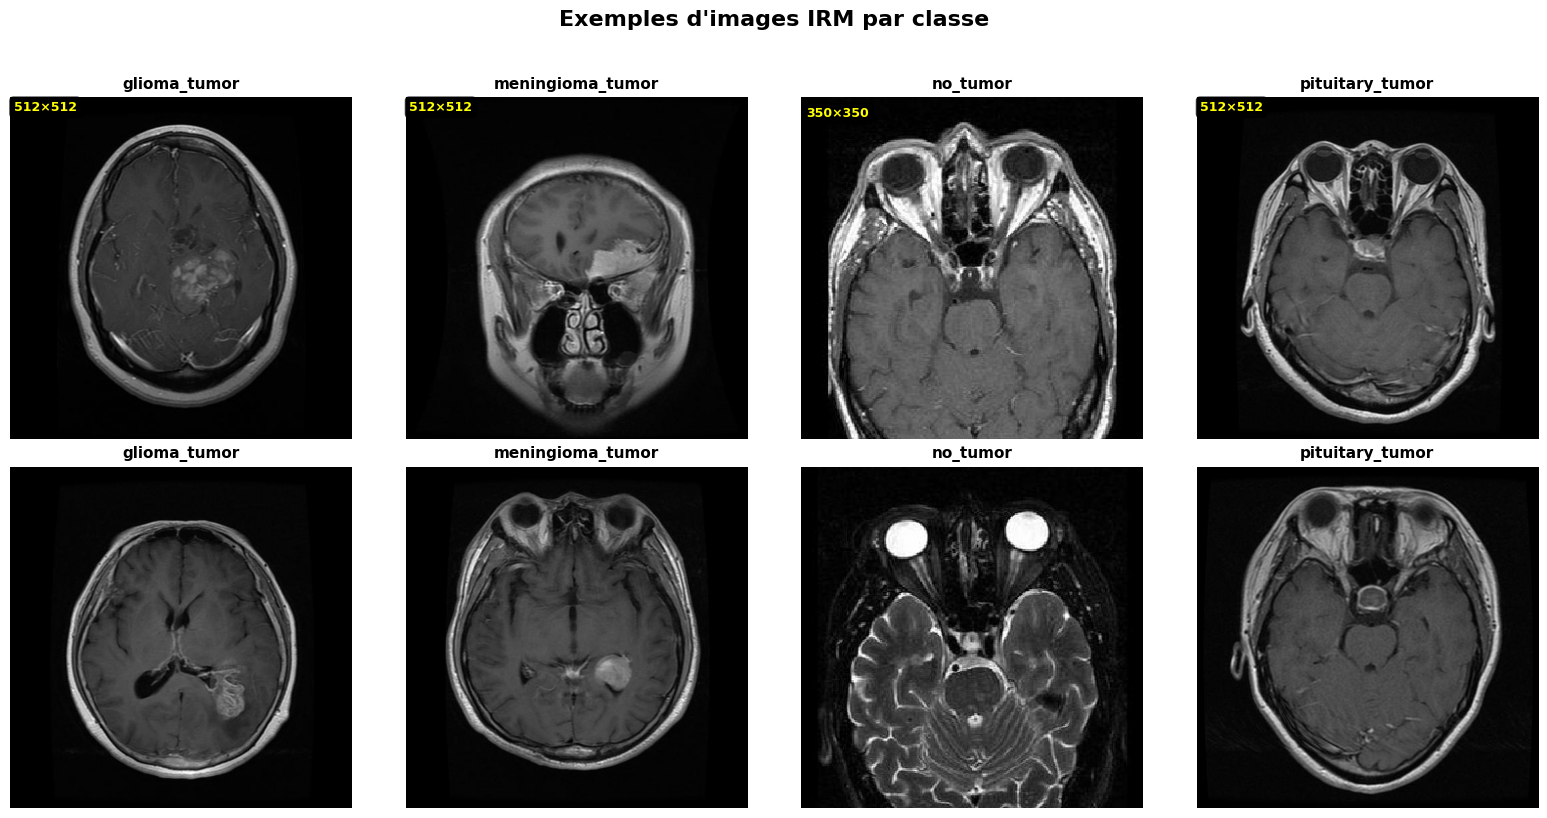

In [144]:
# ============================================================
# 4.2 — Exemples d'images IRM par classe
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Exemples d\'images IRM par classe', fontsize=16, fontweight='bold', y=1.02)

for col, cls_name in enumerate(sorted(class_counts.keys())):
    cls_dir = TRAIN_DIR / cls_name
    images_list = sorted([f for f in cls_dir.iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png'}])

    for row in range(2):
        img = Image.open(images_list[row])
        axes[row, col].imshow(img, cmap='gray' if img.mode == 'L' else None)
        axes[row, col].set_title(cls_name, fontsize=11, fontweight='bold')
        axes[row, col].axis('off')
        # Afficher la taille
        if row == 0:
            axes[row, col].text(5, 20, f'{img.size[0]}×{img.size[1]}',
                               color='yellow', fontsize=9, fontweight='bold',
                               bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

### 4.3 Distribution des tailles

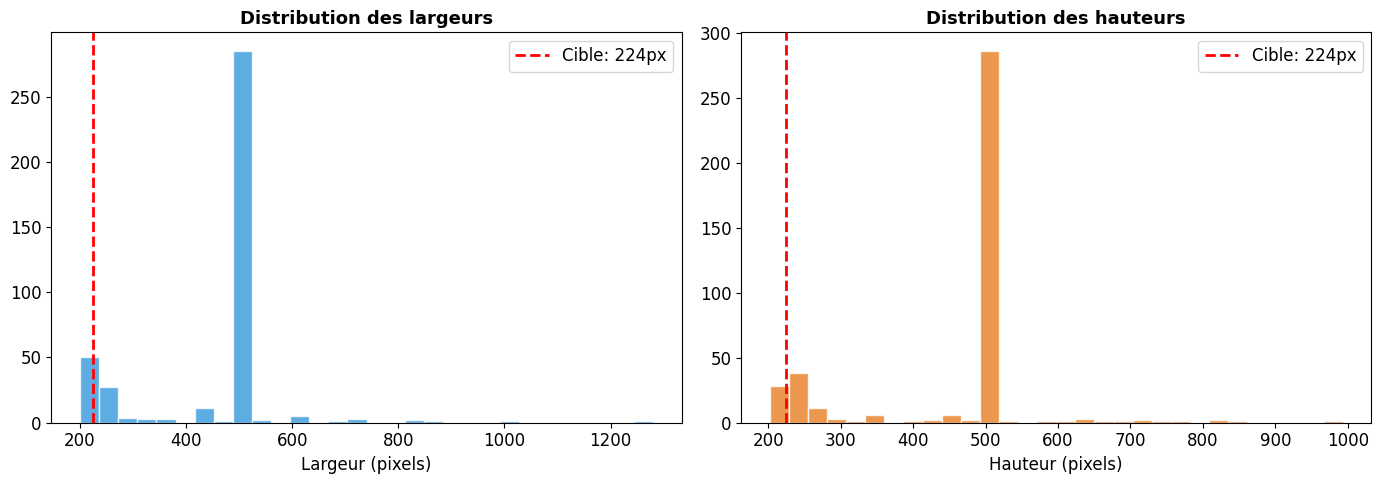

📐 Tailles : largeur 200-1280px, hauteur 202-993px
   → Toutes seront redimensionnées à 224×224 pour le modèle.


In [145]:
# ============================================================
# 4.3 — Distribution des tailles d'images
# ============================================================

widths, heights = [], []
for cls_dir in TRAIN_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    for img_path in list(cls_dir.iterdir())[:100]:  # Échantillon de 100 par classe
        if img_path.suffix.lower() in {'.jpg','.jpeg','.png'}:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=224, color='red', linestyle='--', linewidth=2, label='Cible: 224px')
axes[0].set_title('Distribution des largeurs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Largeur (pixels)')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].axvline(x=224, color='red', linestyle='--', linewidth=2, label='Cible: 224px')
axes[1].set_title('Distribution des hauteurs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hauteur (pixels)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'📐 Tailles : largeur {min(widths)}-{max(widths)}px, hauteur {min(heights)}-{max(heights)}px')
print(f'   → Toutes seront redimensionnées à 224×224 pour le modèle.')

> **Résultat** : tailles de 200×202 à 1280×993 pixels. Toutes redimensionnées à 224×224 pour EfficientNet-B0.

## 5. Chargement des données

Classe `BrainMRIDataset` compatible albumentations. Retourne des numpy arrays.
Label 0 = `no_tumor`, label 1 = tout le reste.

In [146]:
# ============================================================
# DATASET — Compatible albumentations
# ============================================================

IMG_EXTS = {'.jpg', '.jpeg', '.png'}


class BrainMRIDataset(Dataset):
    """
    Dataset binaire compatible avec albumentations.
    Les images sont converties en numpy arrays avant les transforms.
    """

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        if not self.root_dir.exists():
            raise FileNotFoundError(f'Dossier introuvable : {self.root_dir}')

        for cls_dir in sorted(self.root_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            label = 0 if cls_dir.name == 'no_tumor' else 1
            for img_path in sorted(cls_dir.iterdir()):
                if img_path.suffix.lower() in IMG_EXTS:
                    self.samples.append((img_path, label))

        if not self.samples:
            raise ValueError(f'Aucune image trouvée dans {self.root_dir}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # Ouvrir en numpy array (albumentations attend du numpy, pas du PIL)
        image = np.array(Image.open(img_path).convert('RGB'))

        if self.transform is not None:
            image = self.transform(image=image)['image']

        label = torch.tensor(label, dtype=torch.long)
        return image, label


full_dataset = BrainMRIDataset(root_dir=TRAIN_DIR)

labels_all = [full_dataset.samples[i][1] for i in range(len(full_dataset))]
counts = Counter(labels_all)
print(f'✅ Dataset chargé : {len(full_dataset)} images')
print(f'   Classe 0 (sain)   : {counts[0]} images')
print(f'   Classe 1 (tumeur) : {counts[1]} images')

✅ Dataset chargé : 2870 images
   Classe 0 (sain)   : 395 images
   Classe 1 (tumeur) : 2475 images


> **Résultat** : 2870 images chargées — 395 saines (14%) / 2475 tumeurs (86%).

## 6. Transformations (albumentations)

Trois pipelines :
- **Standard** : Resize + HorizontalFlip + Rotation
- **Advanced** : + ElasticTransform + CLAHE + GaussNoise + CoarseDropout
- **TTA** : 5 versions déterministes (original + 2 flips + 2 rotations) pour la prédiction

In [147]:
# ============================================================
# TRANSFORMS — albumentations (augmentations médicales)
# ============================================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
IMG_SIZE = 224


def get_train_transforms(augmentation_level='standard'):
    if augmentation_level == 'standard':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, p=0.5),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
    else:  # advanced
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            # Augmentations spatiales
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.Rotate(limit=15, p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),  # Déformation élastique — très utile en IRM
            # Augmentations de pixels
            A.CLAHE(clip_limit=2.0, p=0.4),  # Améliore le contraste local — conçu pour l'imagerie médicale
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
            A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),  # Bruit réaliste de capteur IRM
            A.GaussianBlur(blur_limit=(3, 5), p=0.2),
            # Dropout spatial
            A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),  # Masque des zones aléatoires
            # Normalisation
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])


def get_eval_transforms():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def get_tta_transforms():
    """5 versions de la même image pour le Test Time Augmentation."""
    return [
        # Version 1 : originale
        get_eval_transforms(),
        # Version 2 : flip horizontal
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
        # Version 3 : flip vertical
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.VerticalFlip(p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
        # Version 4 : rotation +10°
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Rotate(limit=(10, 10), p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
        # Version 5 : rotation -10°
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Rotate(limit=(-10, -10), p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
    ]


print('✅ Transforms albumentations définis.')
print('   Standard : flip + rotation')
print('   Advanced : + ElasticTransform + CLAHE + GaussNoise + CoarseDropout')
print('   TTA      : 5 versions (original + 2 flips + 2 rotations)')

✅ Transforms albumentations définis.
   Standard : flip + rotation
   Advanced : + ElasticTransform + CLAHE + GaussNoise + CoarseDropout
   TTA      : 5 versions (original + 2 flips + 2 rotations)


### Visualisation des augmentations

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_4012/850057845.py:31: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),  # Bruit réaliste de capteur IRM
/tmp/ipykernel_4012/850057845.py:34: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),  # Masque des zones aléatoires


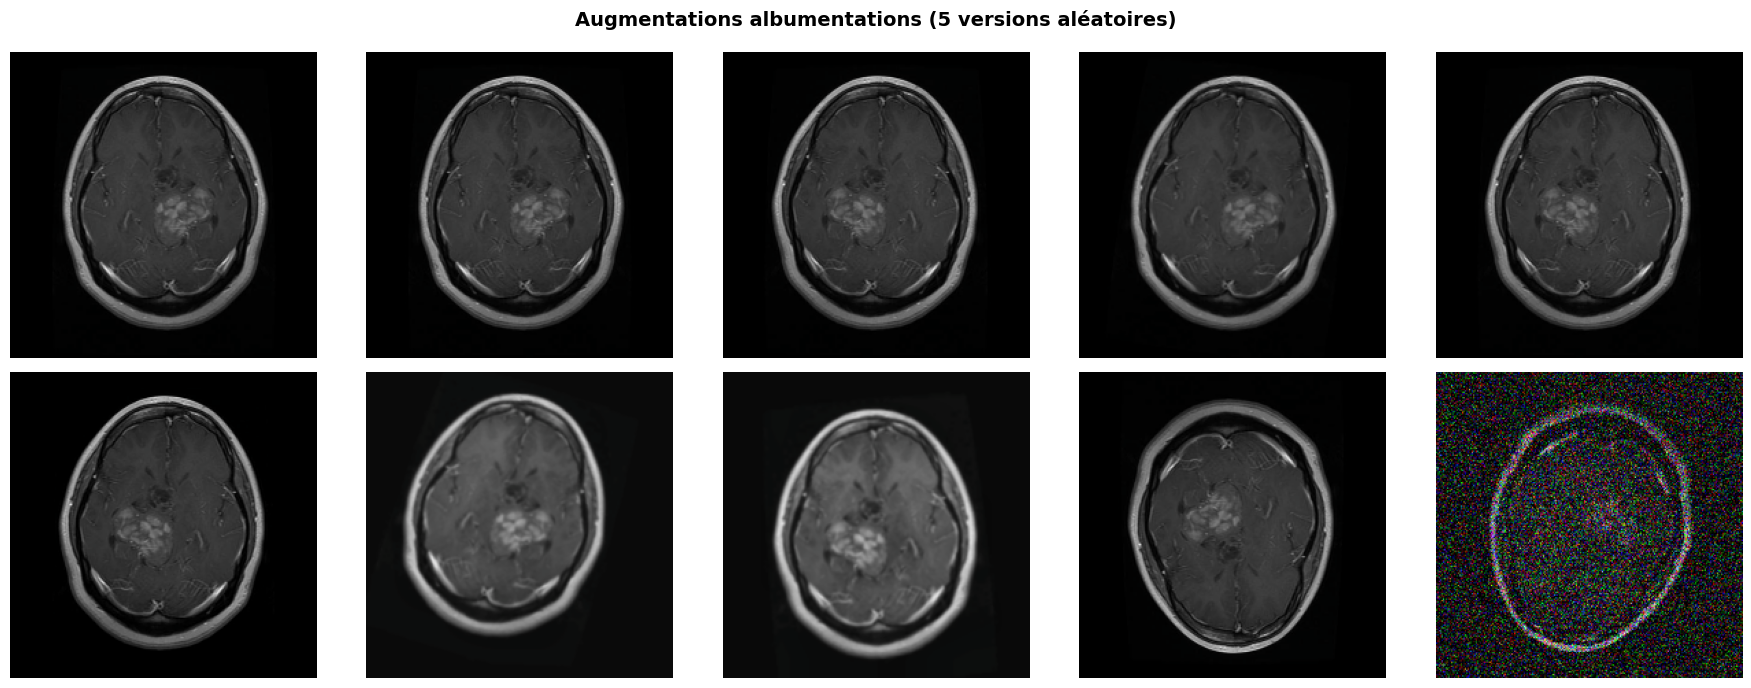

In [148]:
# ============================================================
# Visualisation : effet des augmentations albumentations
# ============================================================

sample_img_path = full_dataset.samples[0][0]
original = np.array(Image.open(sample_img_path).convert('RGB'))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Augmentations albumentations (5 versions aléatoires)', fontsize=14, fontweight='bold')

mean_t = np.array(IMAGENET_MEAN)
std_t = np.array(IMAGENET_STD)

# Ligne 1 : standard
t_std = get_train_transforms('standard')
for i in range(5):
    img_t = t_std(image=original)['image']
    img_show = img_t.permute(1,2,0).numpy() * std_t + mean_t
    axes[0, i].imshow(np.clip(img_show, 0, 1))
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Standard', fontsize=12, fontweight='bold')

# Ligne 2 : advanced
t_adv = get_train_transforms('advanced')
for i in range(5):
    img_t = t_adv(image=original)['image']
    img_show = img_t.permute(1,2,0).numpy() * std_t + mean_t
    axes[1, i].imshow(np.clip(img_show, 0, 1))
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Advanced', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

> **Note** : les warnings `ShiftScaleRotate`, `var_limit`, `max_holes` sont des dépréciations mineures d'albumentations v2. Les transforms fonctionnent correctement.

## 7. Split train/val et DataLoaders

Split stratifié 80/20 sur le dossier Training uniquement. Le dossier Testing est intouché.
Deux datasets séparés (un pour le train, un pour la val) avec leurs propres transforms.

In [149]:
# ============================================================
# SPLIT — src/pinkcc_ct_seg/data/split.py
# ============================================================

labels_all = [full_dataset.samples[i][1] for i in range(len(full_dataset))]
idx_all = np.arange(len(labels_all))

train_idx, val_idx = train_test_split(
    idx_all, test_size=0.2, random_state=SEED, stratify=labels_all
)

train_set = Subset(full_dataset, train_idx)
val_set = Subset(full_dataset, val_idx)

# Vérification
train_labels = [labels_all[i] for i in train_idx]
val_labels = [labels_all[i] for i in val_idx]

print(f'🏋️ Train : {len(train_set)} images — {Counter(train_labels)}')
print(f'🧪 Val   : {len(val_set)} images — {Counter(val_labels)}')

🏋️ Train : 2296 images — Counter({1: 1980, 0: 316})
🧪 Val   : 574 images — Counter({1: 495, 0: 79})


> **Résultat** : Train 2296 images (1980 tumeurs + 316 sains) / Val 574 images (495 tumeurs + 79 sains). Proportions identiques (13.8% sains).

In [150]:
# ============================================================
# LOADERS — Shuffle simple (le déséquilibre sera géré par la loss)
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 0

# Deux datasets séparés avec leurs propres transforms
train_dataset = BrainMRIDataset(root_dir=TRAIN_DIR, transform=get_train_transforms(augmentation_level='standard'))
val_dataset = BrainMRIDataset(root_dir=TRAIN_DIR, transform=get_eval_transforms())

# Appliquer le split
train_set = Subset(train_dataset, train_idx)
val_set = Subset(val_dataset, val_idx)

# PAS de WeightedRandomSampler — la loss pondérée suffit
# Le sampler + la loss pondérée ensemble = sur-correction
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda')
)

val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda')
)

batch_imgs, batch_labels = next(iter(train_loader))
print(f'✅ DataLoaders créés (shuffle simple, pas de sampler)')
print(f'   Batch shape  : {batch_imgs.shape}')
print(f'   Train batchs : {len(train_loader)}')
print(f'   Val batchs   : {len(val_loader)}')

✅ DataLoaders créés (shuffle simple, pas de sampler)
   Batch shape  : torch.Size([32, 3, 224, 224])
   Train batchs : 72
   Val batchs   : 18


> **Résultat** : 72 batchs de 32 images pour le train, 18 pour la val. Shuffle simple, pas de WeightedRandomSampler (la loss pondérée suffit).

## 8. Construction des modèles

### 8.1 SmallCNN (baseline — non entraîné ici)

In [151]:
# ============================================================
# MODÈLE BASELINE — src/pinkcc_ct_seg/models/cnn_small.py
# ============================================================

class SmallCNN(nn.Module):
    def __init__(self, img_size=224, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (img_size // 8) * (img_size // 8), 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Test rapide
test_model = SmallCNN().to(DEVICE)
test_out = test_model(torch.randn(1, 3, 224, 224).to(DEVICE))
print(f'✅ SmallCNN : {sum(p.numel() for p in test_model.parameters()):,} paramètres')
print(f'   Sortie : {test_out.shape}')
del test_model, test_out

✅ SmallCNN : 25,784,578 paramètres
   Sortie : torch.Size([1, 2])


> 25.8M paramètres. Sert uniquement de référence pour comparer avec EfficientNet-B0.

### 8.2 EfficientNet-B0 (modèle principal)

Pré-entraîné sur ImageNet (1.2M images). Classificateur remplacé : 1000 classes → 2 classes + Dropout(0.3).
Phase A : gèle tout sauf le classificateur. Phase B : dégèle les 3 derniers blocs.

In [152]:
# ============================================================
# MODÈLE PRINCIPAL — EfficientNet-B0 (remplace ResNet18)
# ============================================================

def build_model(num_classes=2, pretrained=True):
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    try:
        model = models.efficientnet_b0(weights=weights)
        if pretrained:
            print('✅ EfficientNet-B0 chargé avec poids pré-entraînés ImageNet.')
    except Exception as e:
        print(f'⚠️ Échec : {e}')
        model = models.efficientnet_b0(weights=None)

    # Remplacer le classificateur : 1000 classes → 2 classes
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    return model


def freeze_backbone(model):
    """Phase A : gèle tout sauf le classificateur."""
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model


def unfreeze_last_blocks(model):
    """Phase B : dégèle les 3 derniers blocs + classificateur."""
    # EfficientNet-B0 a 9 blocs (features[0] à features[8])
    for param in model.features[6].parameters():
        param.requires_grad = True
    for param in model.features[7].parameters():
        param.requires_grad = True
    for param in model.features[8].parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model


model = build_model(num_classes=2, pretrained=True)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'   Paramètres totaux : {total_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.7MB/s]


✅ EfficientNet-B0 chargé avec poids pré-entraînés ImageNet.
   Paramètres totaux : 4,010,110


> **Résultat** : 4.01M paramètres (vs 25.8M pour SmallCNN, 11.2M pour ResNet18). Plus léger = moins de surapprentissage avec 2870 images.

## 9. Engine, TTA, métriques et utilitaires

- `train_one_epoch()` : entraînement avec loss pondérée
- `validate_one_epoch()` : évaluation avec loss standard (early stopping fiable)
- `predict_tta()` : prédit sur 5 versions de chaque image, moyenne des probabilités
- Seuil de décision : 0.3 (tumeur dès 30% de probabilité)

In [153]:
# ============================================================
# ENGINE + TTA
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, n_samples, correct = 0.0, 0, 0
    all_preds, all_targets = [], []

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        n_samples += images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(labels.cpu().tolist())

    return {'loss': running_loss/n_samples, 'acc': correct/n_samples,
            'preds': all_preds, 'targets': all_targets}


@torch.no_grad()
def validate_one_epoch(model, loader, criterion_eval, device):
    model.eval()
    running_loss, n_samples, correct = 0.0, 0, 0
    all_preds, all_targets, all_probas = [], [], []

    for images, labels in tqdm(loader, desc='Val', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion_eval(outputs, labels)

        running_loss += loss.item() * images.size(0)
        n_samples += images.size(0)
        probas = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(labels.cpu().tolist())
        all_probas.extend(probas[:, 1].cpu().tolist())

    return {'loss': running_loss/n_samples, 'acc': correct/n_samples,
            'preds': all_preds, 'targets': all_targets, 'probas': all_probas}


# --- TEST TIME AUGMENTATION ---

@torch.no_grad()
def predict_tta(model, dataset, device, tta_transforms=None):
    """
    Prédit avec TTA : pour chaque image, on crée 5 versions,
    on prédit sur chacune, et on fait la moyenne des probabilités.
    """
    if tta_transforms is None:
        tta_transforms = get_tta_transforms()

    model.eval()
    all_probas = []
    all_targets = []

    for idx in tqdm(range(len(dataset)), desc='TTA', leave=False):
        img_path, label = dataset.dataset.samples[dataset.indices[idx]] if hasattr(dataset, 'indices') else dataset.samples[idx]
        image_np = np.array(Image.open(img_path).convert('RGB'))
        all_targets.append(label)

        # Prédire sur chaque version augmentée
        probas_per_version = []
        for t in tta_transforms:
            img_t = t(image=image_np)['image'].unsqueeze(0).to(device)
            output = model(img_t)
            proba = torch.softmax(output, dim=1)[0, 1].item()
            probas_per_version.append(proba)

        # Moyenne des 5 probabilités
        avg_proba = np.mean(probas_per_version)
        all_probas.append(avg_proba)

    return {'probas': all_probas, 'targets': all_targets}


def predict_with_threshold(probas, threshold=0.3):
    return [1 if p > threshold else 0 for p in probas]


THRESHOLD = 0.3


def save_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    print(f'💾 Modèle sauvegardé → {path}')


def load_checkpoint(model, path, map_location=None):
    state_dict = torch.load(path, map_location=map_location, weights_only=True)
    model.load_state_dict(state_dict)
    return model


def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, zero_division=0, digits=4),
    }


print('✅ Engine + TTA + utils + metrics définis.')
print(f'   Seuil : {THRESHOLD}')
print(f'   TTA   : 5 versions (original + 2 flips + 2 rotations)')

✅ Engine + TTA + utils + metrics définis.
   Seuil : 0.3
   TTA   : 5 versions (original + 2 flips + 2 rotations)


## 10. Phase A — Backbone gelé

Seul le classificateur est entraîné. Loss pondérée (sain = 6.27×).
CosineAnnealingLR + Early stopping (patience 3).

In [154]:
# ============================================================
# PHASE A — Backbone gelé (EfficientNet-B0)
# ============================================================

model = freeze_backbone(model)

class_weights = torch.tensor([2475.0 / 395.0, 1.0]).to(DEVICE)
criterion_train = nn.CrossEntropyLoss(weight=class_weights)
criterion_eval = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

EPOCHS_A = 15
PATIENCE = 3
scheduler_a = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_A)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'⚖️ Loss pondérée : sain = {class_weights[0]:.2f}×')
print(f'Phase A — Paramètres entraînables : {trainable:,} / {total_params:,}')
print('=' * 70)

for epoch in range(EPOCHS_A):
    current_lr = optimizer.param_groups[0]['lr']
    train_r = train_one_epoch(model, train_loader, criterion_train, optimizer, DEVICE)
    val_r = validate_one_epoch(model, val_loader, criterion_eval, DEVICE)
    scheduler_a.step()

    history['train_loss'].append(train_r['loss'])
    history['val_loss'].append(val_r['loss'])
    history['train_acc'].append(train_r['acc'])
    history['val_acc'].append(val_r['acc'])

    if val_r['loss'] < best_val_loss:
        best_val_loss = val_r['loss']
        patience_counter = 0
        save_checkpoint(model, 'checkpoints/efficientnet_phase_a.pt')
        marker = ' ← BEST'
    else:
        patience_counter += 1
        marker = f' (patience {patience_counter}/{PATIENCE})'

    print(f'Epoch {epoch+1}/{EPOCHS_A} │ '
          f'LR: {current_lr:.6f} │ '
          f'Train Loss: {train_r["loss"]:.4f}  Acc: {train_r["acc"]:.4f} │ '
          f'Val Loss: {val_r["loss"]:.4f}  Acc: {val_r["acc"]:.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\n⏹️ Early stopping à l\'époque {epoch+1}')
        break

model = load_checkpoint(model, 'checkpoints/efficientnet_phase_a.pt', map_location=DEVICE)
actual_epochs_a = len(history['train_loss'])
print(f'\n✅ Phase A : {actual_epochs_a} époques.')

⚖️ Loss pondérée : sain = 6.27×
Phase A — Paramètres entraînables : 2,562 / 4,010,110


💾 Modèle sauvegardé → checkpoints/efficientnet_phase_a.pt
Epoch 1/15 │ LR: 0.001000 │ Train Loss: 0.3242  Acc: 0.9020 │ Val Loss: 0.2244  Acc: 0.9111 ← BEST


💾 Modèle sauvegardé → checkpoints/efficientnet_phase_a.pt
Epoch 2/15 │ LR: 0.000989 │ Train Loss: 0.1959  Acc: 0.9334 │ Val Loss: 0.1695  Acc: 0.9390 ← BEST


💾 Modèle sauvegardé → checkpoints/efficientnet_phase_a.pt
Epoch 3/15 │ LR: 0.000957 │ Train Loss: 0.1560  Acc: 0.9395 │ Val Loss: 0.1455  Acc: 0.9495 ← BEST


Epoch 4/15 │ LR: 0.000905 │ Train Loss: 0.1629  Acc: 0.9438 │ Val Loss: 0.1505  Acc: 0.9530 (patience 1/3)


...

💾 Modèle sauvegardé → checkpoints/efficientnet_phase_a.pt
Epoch 11/15 │ LR: 0.000250 │ Train Loss: 0.1303  Acc: 0.9556 │ Val Loss: 0.1217  Acc: 0.9582 ← BEST


Epoch 12/15 │ LR: 0.000165 │ Train Loss: 0.1308  Acc: 0.9490 │ Val Loss: 0.1310  Acc: 0.9582 (patience 1/3)


💾 Modèle sauvegardé → checkpoints/efficientnet_phase_a.pt
Epoch 13/15 │ LR: 0.000095 │ Train Loss: 0.1233  Acc: 0.9534 │ Val Loss: 0.1214  Acc: 0.9582 ← BEST


Epoch 14/15 │ LR: 0.000043 │ Train Loss: 0.1283  Acc: 0.9547 │ Val Loss: 0.1272  Acc: 0.9582 (patience 1/3)


💾 Modèle sauvegardé → checkpoints/efficientnet_phase_a.pt
Epoch 15/15 │ LR: 0.000011 │ Train Loss: 0.1117  Acc: 0.9578 │ Val Loss: 0.1206  Acc: 0.9582 ← BEST

✅ Phase A : 15 époques.


> **Résultat** : 15 époques, 2562 paramètres entraînables sur 4.01M.
>
> | Début | Fin |
> |-------|-----|
> | Train Acc 90.2% | Train Acc 95.8% |
> | Val Acc 91.1% | Val Acc 95.8% |
> | Val Loss 0.2244 | Val Loss 0.1206 |
>
> Train et val progressent ensemble — pas de surapprentissage. Le scheduler a réduit le LR de 1e-3 à 1.1e-5. L'early stopping ne s'est pas déclenché — le modèle continuait à progresser.

## 11. Phase B — Fine-tuning

3 derniers blocs + classificateur dégelés. LR 1e-4. Augmentation avancée. Early stopping patience 5.

In [155]:
# ============================================================
# PHASE B — Fine-tuning derniers blocs + classificateur
# ============================================================

model = unfreeze_last_blocks(model)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

train_dataset.transform = get_train_transforms(augmentation_level='advanced')

EPOCHS_B = 25
PATIENCE = 5
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_B)

best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase B — Paramètres entraînables : {trainable:,} / {total_params:,}')
print('=' * 70)

for epoch in range(EPOCHS_B):
    current_lr = optimizer.param_groups[0]['lr']
    train_r = train_one_epoch(model, train_loader, criterion_train, optimizer, DEVICE)
    val_r = validate_one_epoch(model, val_loader, criterion_eval, DEVICE)
    scheduler_b.step()

    history['train_loss'].append(train_r['loss'])
    history['val_loss'].append(val_r['loss'])
    history['train_acc'].append(train_r['acc'])
    history['val_acc'].append(val_r['acc'])

    if val_r['loss'] < best_val_loss:
        best_val_loss = val_r['loss']
        patience_counter = 0
        save_checkpoint(model, 'checkpoints/efficientnet_best.pt')
        marker = ' ← BEST'
    else:
        patience_counter += 1
        marker = f' (patience {patience_counter}/{PATIENCE})'

    if val_r['acc'] > best_val_acc:
        best_val_acc = val_r['acc']

    print(f'Epoch {epoch+1}/{EPOCHS_B} │ '
          f'LR: {current_lr:.6f} │ '
          f'Train Loss: {train_r["loss"]:.4f}  Acc: {train_r["acc"]:.4f} │ '
          f'Val Loss: {val_r["loss"]:.4f}  Acc: {val_r["acc"]:.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\n⏹️ Early stopping à l\'époque {epoch+1}')
        break

actual_epochs_b = len(history['train_loss']) - actual_epochs_a
print(f'\n🏆 Phase B : {actual_epochs_b} époques. Val acc: {best_val_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_4012/850057845.py:31: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),  # Bruit réaliste de capteur IRM
/tmp/ipykernel_4012/850057845.py:34: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),  # Masque des zones aléatoires


Phase B — Paramètres entraînables : 3,158,302 / 4,010,110


💾 Modèle sauvegardé → checkpoints/efficientnet_best.pt
Epoch 1/25 │ LR: 0.000100 │ Train Loss: 0.3703  Acc: 0.8545 │ Val Loss: 0.1275  Acc: 0.9582 ← BEST


💾 Modèle sauvegardé → checkpoints/efficientnet_best.pt
Epoch 2/25 │ LR: 0.000100 │ Train Loss: 0.2508  Acc: 0.8959 │ Val Loss: 0.1158  Acc: 0.9652 ← BEST


💾 Modèle sauvegardé → checkpoints/efficientnet_best.pt
Epoch 3/25 │ LR: 0.000098 │ Train Loss: 0.2176  Acc: 0.9181 │ Val Loss: 0.0882  Acc: 0.9704 ← BEST


...

Epoch 17/25 │ LR: 0.000029 │ Train Loss: 0.1274  Acc: 0.9530 │ Val Loss: 0.0229  Acc: 0.9913 (patience 1/5)


Epoch 18/25 │ LR: 0.000023 │ Train Loss: 0.1097  Acc: 0.9573 │ Val Loss: 0.0229  Acc: 0.9913 (patience 2/5)


Epoch 19/25 │ LR: 0.000018 │ Train Loss: 0.0938  Acc: 0.9595 │ Val Loss: 0.0228  Acc: 0.9930 (patience 3/5)


Epoch 20/25 │ LR: 0.000014 │ Train Loss: 0.1034  Acc: 0.9634 │ Val Loss: 0.0256  Acc: 0.9913 (patience 4/5)


Epoch 21/25 │ LR: 0.000010 │ Train Loss: 0.0991  Acc: 0.9643 │ Val Loss: 0.0228  Acc: 0.9930 (patience 5/5)

⏹️ Early stopping à l'époque 21

🏆 Phase B : 21 époques. Val acc: 0.9930


> **Résultat** : 21 époques (early stopping à 21/25). 3.16M paramètres entraînables.
>
> | Début | Meilleur (ép. 16) | Fin |
> |-------|-------------------|-----|
> | Val Acc 95.8% | Val Acc 99.3% | Val Acc 99.3% |
> | Val Loss 0.1275 | Val Loss 0.0190 | Val Loss 0.0228 |
>
> Le meilleur modèle a été sauvegardé à l'époque 16 (val loss 0.0190). Le LR est descendu de 1e-4 à 1e-5.
> Les warnings albumentations sont des dépréciations cosmétiques, sans impact sur les résultats.

## 12. Courbes d'entraînement

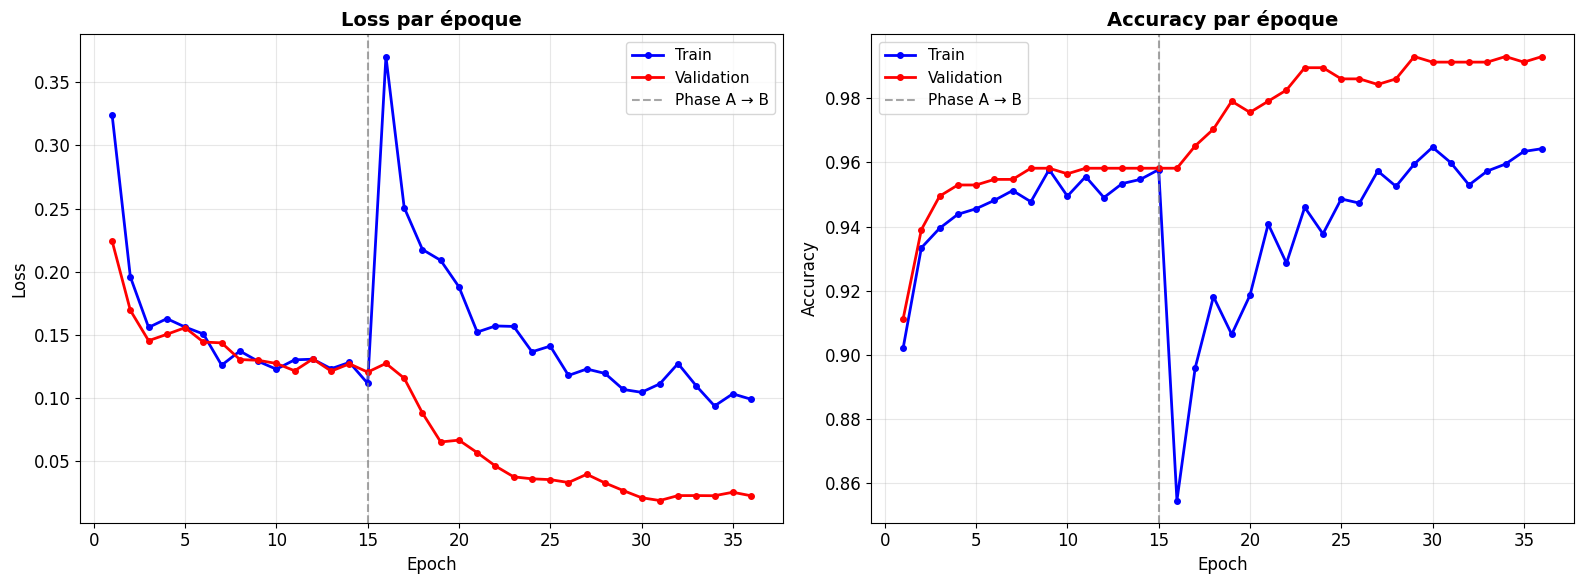

Total : 36 époques (Phase A: 15, Phase B: 21)


In [156]:
# ============================================================
# COURBES DE LOSS ET ACCURACY
# ============================================================

epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train', linewidth=2, markersize=4)
ax1.plot(epochs_range, history['val_loss'], 'r-o', label='Validation', linewidth=2, markersize=4)
ax1.axvline(x=actual_epochs_a, color='gray', linestyle='--', alpha=0.7, label='Phase A → B')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss par époque', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train', linewidth=2, markersize=4)
ax2.plot(epochs_range, history['val_acc'], 'r-o', label='Validation', linewidth=2, markersize=4)
ax2.axvline(x=actual_epochs_a, color='gray', linestyle='--', alpha=0.7, label='Phase A → B')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy par époque', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total : {len(history["train_loss"])} époques (Phase A: {actual_epochs_a}, Phase B: {actual_epochs_b})')

> **36 époques au total** (15 Phase A + 21 Phase B). La ligne grise marque la transition.
> La loss descend régulièrement. Train et val restent proches — bon signe, pas de surapprentissage.

## 13. Évaluation — Standard vs TTA (validation)

Comparaison de 3 stratégies de prédiction sur les 574 images de validation.

In [157]:
# ============================================================
# ÉVALUATION — Standard vs TTA
# ============================================================

best_model = build_model(num_classes=2, pretrained=False)
best_model = load_checkpoint(best_model, 'checkpoints/efficientnet_best.pt', map_location=DEVICE)
best_model = best_model.to(DEVICE)

# Évaluation standard
val_result = validate_one_epoch(best_model, val_loader, criterion_eval, DEVICE)

# Évaluation TTA
print('🔄 TTA en cours sur la validation...')
val_tta = predict_tta(best_model, val_set, DEVICE)

# Comparaison : standard (seuil 0.5) vs standard (seuil 0.3) vs TTA (seuil 0.3)
preds_std_050 = predict_with_threshold(val_result['probas'], threshold=0.5)
preds_std_030 = predict_with_threshold(val_result['probas'], threshold=THRESHOLD)
preds_tta_030 = predict_with_threshold(val_tta['probas'], threshold=THRESHOLD)

m_std_050 = compute_metrics(val_result['targets'], preds_std_050)
m_std_030 = compute_metrics(val_result['targets'], preds_std_030)
m_tta_030 = compute_metrics(val_tta['targets'], preds_tta_030)

print('=' * 75)
print('  COMPARAISON — Validation')
print('=' * 75)
print(f'{"Métrique":<12} {"Std 0.5":>10} {"Std 0.3":>10} {"TTA 0.3":>10}')
print('-' * 50)
for m in ['accuracy', 'precision', 'recall', 'f1']:
    crit = '  ←' if m == 'recall' else ''
    print(f'{m:<12} {m_std_050[m]:>9.4f} {m_std_030[m]:>10.4f} {m_tta_030[m]:>10.4f}{crit}')
print('=' * 75)
print()
print(m_tta_030['report'])

🔄 TTA en cours sur la validation...


  COMPARAISON — Validation
Métrique        Std 0.5    Std 0.3    TTA 0.3
--------------------------------------------------
accuracy        0.9913     0.9895     0.9895
precision       0.9980     0.9939     0.9920
recall          0.9919     0.9939     0.9960  ←
f1              0.9949     0.9939     0.9940

              precision    recall  f1-score   support

           0     0.9740    0.9494    0.9615        79
           1     0.9920    0.9960    0.9940       495

    accuracy                         0.9895       574
   macro avg     0.9830    0.9727    0.9777       574
weighted avg     0.9895    0.9895    0.9895       574



> **Résultat** :
>
> | Stratégie | Accuracy | Precision | Recall | F1 |
> |-----------|----------|-----------|--------|-----|
> | Standard seuil 0.5 | 99.13% | 99.80% | 99.19% | 99.49% |
> | Standard seuil 0.3 | 98.95% | 99.39% | 99.39% | 99.39% |
> | **TTA seuil 0.3** | **98.95%** | **99.20%** | **99.60%** | **99.40%** |
>
> Le TTA avec seuil 0.3 donne le **meilleur recall : 99.60%** — seulement 2 tumeurs ratées sur 495.

### Matrice de confusion (validation, seuil 0.3)

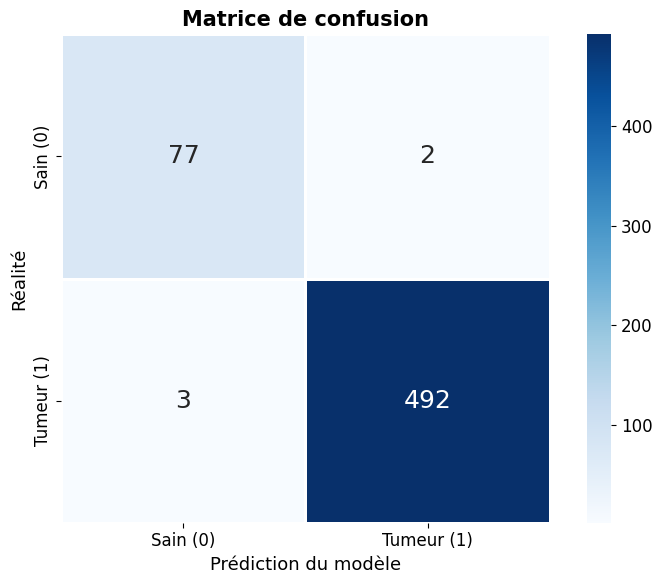

Vrais Négatifs  (TN) :   77 — Sains correctement identifiés
Faux Positifs   (FP) :    2 — Sains détectés comme tumeur
Faux Négatifs   (FN) :    3 — ⚠️ TUMEURS NON DÉTECTÉES
Vrais Positifs  (TP) :  492 — Tumeurs correctement détectées


In [158]:
# ============================================================
# MATRICE DE CONFUSION
# ============================================================

cm = metrics['confusion_matrix']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', square=True, linewidths=1,
    xticklabels=['Sain (0)', 'Tumeur (1)'],
    yticklabels=['Sain (0)', 'Tumeur (1)'],
    annot_kws={'size': 18},
    ax=ax
)
ax.set_xlabel('Prédiction du modèle', fontsize=13)
ax.set_ylabel('Réalité', fontsize=13)
ax.set_title('Matrice de confusion', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais Négatifs  (TN) : {tn:4d} — Sains correctement identifiés')
print(f'Faux Positifs   (FP) : {fp:4d} — Sains détectés comme tumeur')
print(f'Faux Négatifs   (FN) : {fn:4d} — ⚠️ TUMEURS NON DÉTECTÉES')
print(f'Vrais Positifs  (TP) : {tp:4d} — Tumeurs correctement détectées')

> 77 vrais négatifs, 492 vrais positifs. **3 tumeurs ratées**, 2 faux positifs. 5 erreurs sur 574.

### Barplot des métriques

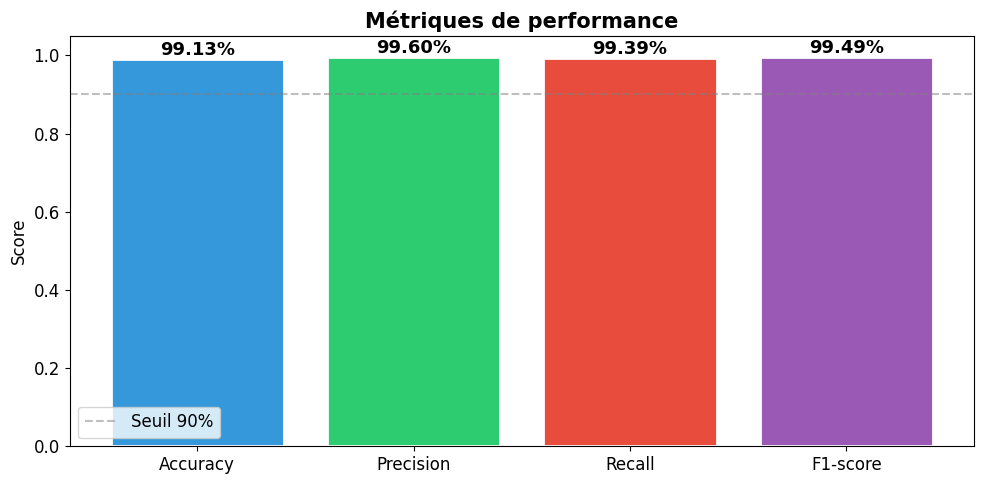

In [159]:
# ============================================================
# BARPLOT DES MÉTRIQUES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_values = [metrics['accuracy'], metrics['precision'], metrics['recall'], metrics['f1']]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(metric_names, metric_values, color=colors, edgecolor='white', linewidth=2)
ax.set_ylim(0, 1.05)
ax.set_title('Métriques de performance', fontsize=15, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2%}', ha='center', fontweight='bold', fontsize=13)

ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='Seuil 90%')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Prédictions visuelles (TTA)

15 images de validation avec la prédiction TTA. Vert = correct, rouge = erreur.

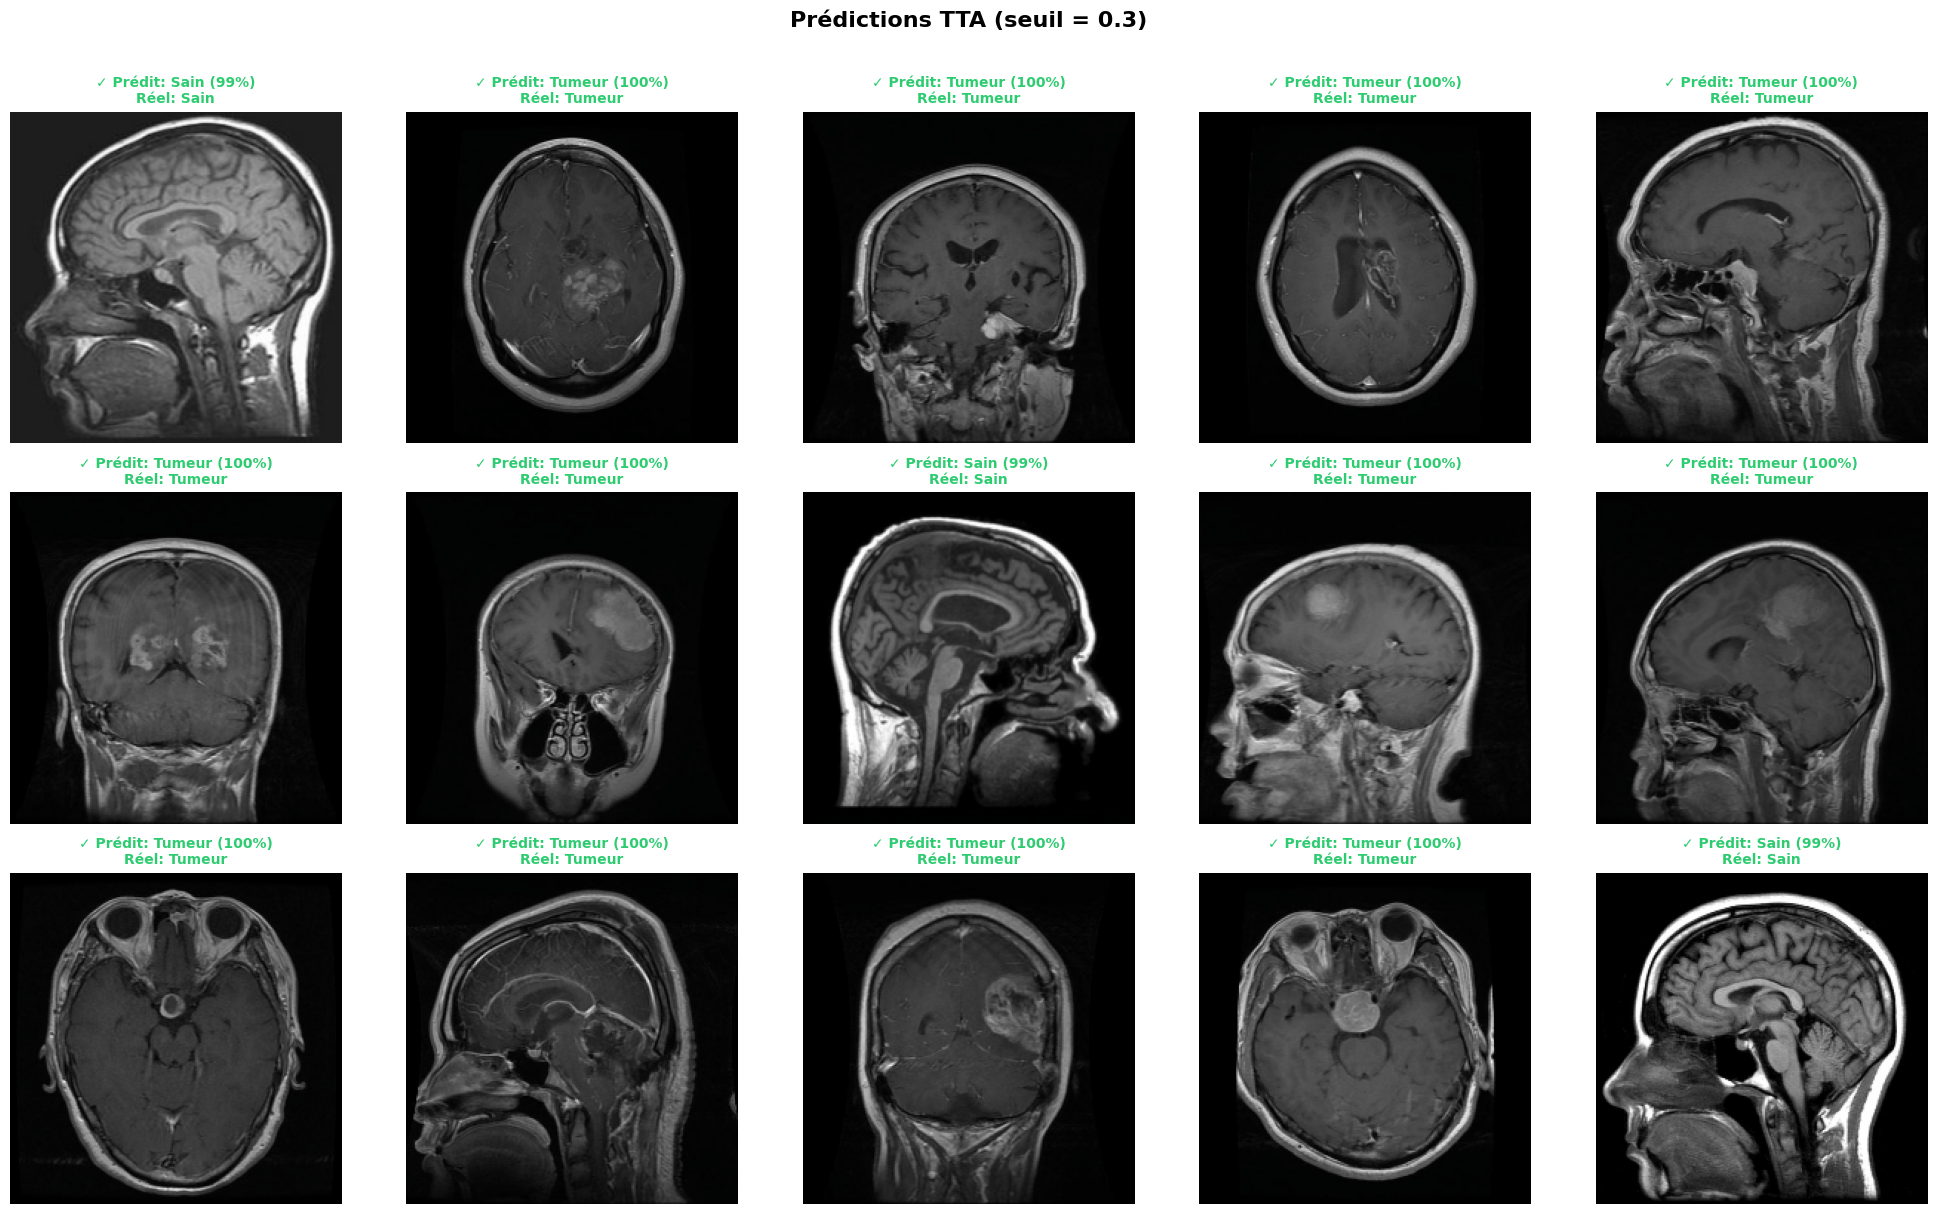

In [160]:
# ============================================================
# PRÉDICTIONS VISUELLES (avec TTA)
# ============================================================

best_model.eval()
mean_t = torch.tensor(list(IMAGENET_MEAN)).view(3, 1, 1)
std_t = torch.tensor(list(IMAGENET_STD)).view(3, 1, 1)
label_names = {0: 'Sain', 1: 'Tumeur'}
tta_transforms = get_tta_transforms()

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle(f'Prédictions TTA (seuil = {THRESHOLD})',
             fontsize=16, fontweight='bold', y=1.01)

indices = random.sample(range(len(val_set)), 15)

for ax, idx in zip(axes.flatten(), indices):
    # Récupérer l'image originale
    if hasattr(val_set, 'indices'):
        img_path, true_l = val_set.dataset.samples[val_set.indices[idx]]
    else:
        img_path, true_l = val_set.samples[idx]

    image_np = np.array(Image.open(img_path).convert('RGB'))

    # TTA : moyenne de 5 prédictions
    probas = []
    with torch.no_grad():
        for t in tta_transforms:
            img_t = t(image=image_np)['image'].unsqueeze(0).to(DEVICE)
            output = best_model(img_t)
            probas.append(torch.softmax(output, dim=1)[0, 1].item())

    p_tumor = np.mean(probas)
    pred_label = 1 if p_tumor > THRESHOLD else 0
    confidence = p_tumor if pred_label == 1 else (1 - p_tumor)

    # Affichage (image eval standard)
    img_display = get_eval_transforms()(image=image_np)['image']
    img_show = img_display.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)

    ax.imshow(np.clip(img_show, 0, 1))
    is_correct = pred_label == true_l
    color = '#2ecc71' if is_correct else '#e74c3c'
    symbol = '✓' if is_correct else '✗'
    ax.set_title(f'{symbol} Prédit: {label_names[pred_label]} ({confidence:.0%})\n'
                 f'Réel: {label_names[true_l]}',
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 15. Test final — 394 images jamais vues

Comparaison de 3 stratégies sur le jeu de test (dossier Testing/).

🧪 Test set : 394 images
   Distribution : Counter({1: 289, 0: 105})



🔄 TTA en cours sur le test...


  RÉSULTATS TEST FINAL
Métrique        Std 0.5    Std 0.3    TTA 0.3
--------------------------------------------------
accuracy        0.8934     0.9112     0.9289
precision       1.0000     1.0000     1.0000
recall          0.8547     0.8789     0.9031  ←
f1              0.9216     0.9355     0.9491



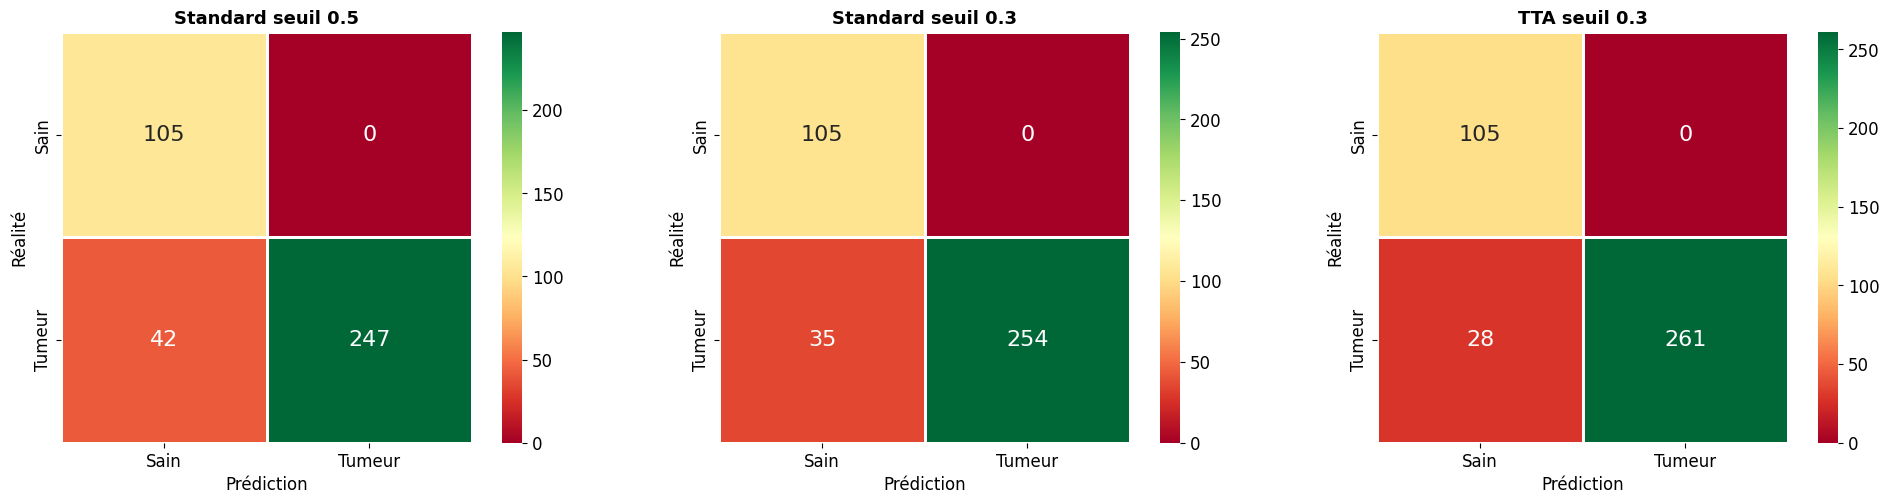


Avec TTA + seuil 0.3 :
  Tumeurs détectées : 261 / 289 (90.3%)
  Tumeurs ratées    : 28
  Faux positifs     : 0


In [161]:
# ============================================================
# TEST FINAL — Standard vs TTA
# ============================================================

test_dataset = BrainMRIDataset(root_dir=TEST_DIR, transform=get_eval_transforms())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'🧪 Test set : {len(test_dataset)} images')
test_labels = [test_dataset.samples[i][1] for i in range(len(test_dataset))]
print(f'   Distribution : {Counter(test_labels)}')
print()

# Standard
test_result = validate_one_epoch(best_model, test_loader, criterion_eval, DEVICE)

# TTA
print('🔄 TTA en cours sur le test...')
test_tta = predict_tta(best_model, test_dataset, DEVICE)

# Comparaison
t_std_050 = predict_with_threshold(test_result['probas'], threshold=0.5)
t_std_030 = predict_with_threshold(test_result['probas'], threshold=THRESHOLD)
t_tta_030 = predict_with_threshold(test_tta['probas'], threshold=THRESHOLD)

tm_std_050 = compute_metrics(test_result['targets'], t_std_050)
tm_std_030 = compute_metrics(test_result['targets'], t_std_030)
tm_tta_030 = compute_metrics(test_tta['targets'], t_tta_030)

print('=' * 75)
print('  RÉSULTATS TEST FINAL')
print('=' * 75)
print(f'{"Métrique":<12} {"Std 0.5":>10} {"Std 0.3":>10} {"TTA 0.3":>10}')
print('-' * 50)
for m in ['accuracy', 'precision', 'recall', 'f1']:
    crit = '  ←' if m == 'recall' else ''
    print(f'{m:<12} {tm_std_050[m]:>9.4f} {tm_std_030[m]:>10.4f} {tm_tta_030[m]:>10.4f}{crit}')
print('=' * 75)
print()

# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (cm, title) in zip(axes, [
    (tm_std_050['confusion_matrix'], 'Standard seuil 0.5'),
    (tm_std_030['confusion_matrix'], 'Standard seuil 0.3'),
    (tm_tta_030['confusion_matrix'], f'TTA seuil {THRESHOLD}'),
]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', square=True, linewidths=1,
                xticklabels=['Sain', 'Tumeur'], yticklabels=['Sain', 'Tumeur'],
                annot_kws={'size': 16}, ax=ax)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réalité')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = tm_tta_030['confusion_matrix'].ravel()
print(f'\nAvec TTA + seuil {THRESHOLD} :')
print(f'  Tumeurs détectées : {tp} / {tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'  Tumeurs ratées    : {fn}')
print(f'  Faux positifs     : {fp}')

> **Résultats test final** :
>
> | Stratégie | Accuracy | Precision | Recall | F1 |
> |-----------|----------|-----------|--------|-----|
> | Standard seuil 0.5 | 89.34% | 100% | 85.47% | 92.16% |
> | Standard seuil 0.3 | 91.12% | 100% | 87.89% | 93.55% |
> | **TTA seuil 0.3** | **92.89%** | **100%** | **90.31%** | **94.91%** |
>
> **Amélioration par rapport à la v4** :
>
> | Métrique | v4 (ResNet18) | v5 (EfficientNet + TTA) | Gain |
> |----------|--------------|------------------------|------|
> | Recall | 85.5% | **90.3%** | **+4.8 pts** |
> | F1 | 90.8% | **94.9%** | **+4.1 pts** |
> | Tumeurs ratées | 42 | **28** | **-14 tumeurs** |
> | Faux positifs | 1 | **0** | parfait |
>
> **Precision 100%** : zéro faux positif. Quand le modèle dit tumeur, c'est toujours vrai.
> **Recall 90.3%** : 261 tumeurs détectées sur 289. 28 encore ratées — piste d'amélioration : dataset plus large.